In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [84]:
# Check what sheets are available in the Excel file
xl_file = pd.ExcelFile("../data/SPFmicrodata.xlsx")
print("Available indicators:", xl_file.sheet_names)

# Load only the NGDP sheet
df = pd.read_excel("../data/SPFmicrodata.xlsx", sheet_name="NGDP")
print(f"\nLoaded NGDP sheet: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:", df.columns.tolist())

Available indicators: ['NGDP', 'PGDP', 'CPROF', 'UNEMP', 'EMP', 'INDPROD', 'HOUSING', 'TBILL', 'BOND', 'BAABOND', 'TBOND', 'RGDP', 'RCONSUM', 'RNRESIN', 'RRESINV', 'RFEDGOV', 'RSLGOV', 'RCBI', 'REXPORT', 'CPI5YR', 'PCE5YR', 'CPI10', 'PCE10', 'RGDP10', 'PROD10', 'STOCK10', 'BOND10', 'BILL10', 'PRGDP', 'PRPGDP', 'PRUNEMP', 'PRCCPI', 'PRCPCE', 'RECESS', 'CPI', 'CORECPI', 'PCE', 'COREPCE', 'UBAR', 'SPR_TBOND_TBILL', 'SPR_BAA_AAA', 'SPR_BAA_TBOND', 'SPR_AAA_TBOND', 'CPIF5', 'PCEF5', 'RR1_TBILL_PGDP', 'RR2_TBILL_PGDP', 'RR3_TBILL_PGDP', 'RR1_TBILL_CPI', 'RR2_TBILL_CPI', 'RR3_TBILL_CPI', 'RR1_TBILL_CCPI', 'RR2_TBILL_CCPI', 'RR3_TBILL_CCPI', 'RR1_TBILL_PCE', 'RR2_TBILL_PCE', 'RR3_TBILL_PCE', 'RR1_TBILL_CPCE', 'RR2_TBILL_CPCE', 'RR3_TBILL_CPCE']

Loaded NGDP sheet: 9145 rows × 12 columns

Column names: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'NGDP1', 'NGDP2', 'NGDP3', 'NGDP4', 'NGDP5', 'NGDP6', 'NGDPA', 'NGDPB']


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [85]:
df.head()

,YEAR,QUARTER,ID,INDUSTRY,NGDP1,NGDP2,NGDP3,NGDP4,NGDP5,NGDP6,NGDPA,NGDPB
0,1968,4,1,NaN,871.0,884.0,895.0,907.0,920.0,938.0,NaN,NaN
1,1968,4,2,NaN,871.0,891.0,910.0,929.0,958.0,973.0,NaN,NaN
2,1968,4,3,NaN,871.0,883.0,894.0,906.0,924.0,944.0,NaN,NaN
3,1968,4,4,NaN,871.0,885.0,891.0,902.0,919.0,937.0,NaN,NaN
4,1968,4,5,NaN,871.0,895.0,913.0,935.0,940.0,970.0,NaN,NaN


In [86]:
print(" Number of unique IDs:", df['ID'].nunique())
print(" Number of unique years:", df['YEAR'].nunique())
print(" Number of na values in NGDP6:", df['NGDP6'].isna().sum())

 Number of unique IDs: 462
 Number of unique years: 58
 Number of na values in NGDP6: 974


Forecasts for the quarterly and annual level of nominal GDP. Seasonally
adjusted, annual rate, billions $. Prior to 1992, these are forecasts for
nominal GNP. Annual forecasts are for the annual average of the quarterly
levels.

First survey to include this variable: 1968:Q4


https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/spf-documentation.pdf?sc_lang=en&hash=8408A4F1BF351A3C268B40F6BC7B95AA


Realized NGDP according to philadelphiafed website


https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/noutput


Columns are the date of the vintage

For each target quarter t in your SPF panel, we want the first available vintage for that quarter — which is the advance estimate, published in the middle of the month immediately following the end of quarter t:

In [87]:
# ── 1. Load the NOUTPUT vintage matrix ────────────────────────────────────────
noutput = pd.read_excel("../data/NOUTPUTQvQd.xlsx")

# The DATE column looks like "1947:Q1" — parse into YEAR and QUARTER
noutput[["YEAR", "QUARTER"]] = (
    noutput["DATE"]
    .str.extract(r"(\d{4}):Q(\d)")
    .astype(int)
)
noutput = noutput.set_index(["YEAR", "QUARTER"])

# Drop the DATE column if still present
noutput = noutput.drop(columns=["DATE"], errors="ignore")

# ── 2. Build a helper: given a target (year, quarter), 
#       return the advance estimate vintage column name ─────────────────────────
def advance_vintage_col(target_year, target_quarter):
    """
    The advance estimate for a given quarter is published
    in the FOLLOWING quarter's vintage.
    e.g. target = 1995 Q2 → advance vintage = NOUTPUT95Q3
    """
    adv_quarter = target_quarter + 1
    adv_year    = target_year

    if adv_quarter > 4:
        adv_quarter = 1
        adv_year    = target_year + 1

    # Column name format: NOUTPUT95Q3 (2-digit year)
    col = f"NOUTPUT{str(adv_year)[2:]}Q{adv_quarter}"
    return col

# ── 3. Extract advance estimate for each target quarter ───────────────────────
def get_advance_estimate(target_year, target_quarter, noutput_df):
    """
    For a given target (year, quarter), return the advance estimate —
    i.e. the value in the FIRST vintage where that quarter was published.
    
    The advance estimate is published in the immediately following quarter:
        Q1 target → Q2 vintage of same year
        Q2 target → Q3 vintage of same year
        Q3 target → Q4 vintage of same year
        Q4 target → Q1 vintage of next year
    """
    col = advance_vintage_col(target_year, target_quarter)
    try:
        val = noutput_df.loc[(target_year, target_quarter), col]
        return val if not pd.isna(val) else np.nan
    except KeyError:
        return np.nan

# ── 4. Sanity check — a few known quarters ────────────────────────────────────
test_cases = [(1995, 2), (1999, 2), (2008, 4), (2020, 2)]
print("Sanity check — advance estimates:")
print(f"{'Target Quarter':<20} {'Vintage Col':<18} {'Value (bn $)'}")
print("-" * 55)
for y, q in test_cases:
    col = advance_vintage_col(y, q)
    val = get_advance_estimate(y, q, noutput)
    print(f"  {y}:Q{q:<16}  {col:<18}  {val:,.1f}")


Sanity check — advance estimates:
Target Quarter       Vintage Col        Value (bn $)
-------------------------------------------------------
  1995:Q2                 NOUTPUT95Q3         7,011.8
  1999:Q2                 NOUTPUT99Q3         8,893.3
  2008:Q4                 NOUTPUT09Q1         14,264.6
  2020:Q2                 NOUTPUT20Q3         19,408.8


Values should be in the thousands of billions and grow over time — that is the sanity check. If they look right, we move to merging with your individual SPF panel.

In [88]:
# ── NOUTPUT vintage matrix (already loaded and indexed) ───────────────────────
# Assumes noutput is indexed by (YEAR, QUARTER) with columns like 'NOUTPUT95Q3'
# ── Horizon offsets (unchanged) ───────────────────────────────────────────────
# NGDP1 = t-1 (previous quarter historical)
# NGDP2 = t+0 (nowcast, current quarter)
# NGDP3 = t+1, NGDP4 = t+2, NGDP5 = t+3, NGDP6 = t+4
horizon_offsets = {
    'NGDP1': -1,
    'NGDP2':  0,
    'NGDP3':  1,
    'NGDP4':  2,
    'NGDP5':  3,
    'NGDP6':  4,
}

# ── Build errors DataFrame ────────────────────────────────────────────────────
errors_df = df[['YEAR', 'QUARTER', 'ID', 'INDUSTRY'] + list(horizon_offsets.keys())].copy()

for col, offset in horizon_offsets.items():

    # Step 1: compute the target (year, quarter) for this horizon
    total   = (errors_df['YEAR'] - 1) * 4 + (errors_df['QUARTER'] - 1) + offset
    t_year  = ((total // 4) + 1).astype(int)
    t_qtr   = ((total  % 4) + 1).astype(int)

    # Step 2: look up the advance estimate from the correct vintage
    gdp_actual = np.array([
        get_advance_estimate(y, q, noutput)
        for y, q in zip(t_year, t_qtr)
    ])

    # Step 3: compute forecast error (forecast - actual)
    errors_df[f'error_{col}'] = errors_df[col].values - gdp_actual
    errors_df.drop(columns=[col], inplace=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
print("Shape:", errors_df.shape)
print("\nError summary (should be small relative to GDP levels ~thousands of bn$):")
for col in [f'error_NGDP{i}' for i in range(1, 7)]:
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.1f}, "
              f"std={errors_df[col].std():.1f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

# print the rows between 1998 Q4 and 2000 Q2 to check the dot-com bust period
mask = ((errors_df['YEAR'] == 1998) & (errors_df['QUARTER'] == 4)) | \
       ((errors_df['YEAR'] == 1999) & (errors_df['QUARTER'].isin([1, 2, 3, 4]))) | \
       ((errors_df['YEAR'] == 2000) & (errors_df['QUARTER'].isin([1, 2])))
print("\nErrors during dot-com bust period (1998 Q4 to 2000 Q2):")
print(errors_df[mask][['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'error_NGDP2', 'error_NGDP3']])


Shape: (9145, 10)

Error summary (should be small relative to GDP levels ~thousands of bn$):
  error_NGDP1: mean=+0.3, std=6.1, nan%=6.1%
  error_NGDP2: mean=-15.0, std=118.9, nan%=6.5%
  error_NGDP3: mean=-20.4, std=258.5, nan%=6.9%
  error_NGDP4: mean=-25.4, std=313.2, nan%=7.5%
  error_NGDP5: mean=-30.7, std=372.2, nan%=7.9%
  error_NGDP6: mean=-32.2, std=441.6, nan%=12.7%

Errors during dot-com bust period (1998 Q4 to 2000 Q2):
      YEAR  QUARTER   ID  INDUSTRY  error_NGDP2  error_NGDP3
4853  1998        4   20       2.0      -29.900      -78.400
4854  1998        4   40       2.0      -63.700     -103.000
4855  1998        4   65       2.0     -103.984     -181.821
4856  1998        4   84       1.0      -34.800      -79.900
4857  1998        4   99       1.0      -89.800     -104.900
...    ...      ...  ...       ...          ...          ...
5101  2000        2  507       3.0     -129.300      -83.300
5102  2000        2  508       2.0      -92.200     -111.000
5103  2000     

In [89]:
print(513 in population_ids)  # Should be False

False


In [90]:
# let's only keep NGDP3 errors for now
errors_df = errors_df[['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'error_NGDP3']].copy()
errors_df['squared_error_NGDP3'] = errors_df['error_NGDP3']**2

errors_df.head()

,YEAR,QUARTER,ID,INDUSTRY,error_NGDP3,squared_error_NGDP3
0,1968,4,1,NaN,-8.4,70.56
1,1968,4,2,NaN,6.6,43.56
2,1968,4,3,NaN,-9.4,88.36
3,1968,4,4,NaN,-12.4,153.76
4,1968,4,5,NaN,9.6,92.16


In [91]:
# Count observations per forecaster alongside their MSE
forecaster_stats = (
    errors_df
    .groupby('ID')['squared_error_NGDP3']
    .agg(mean_mse='mean', n_obs='count')
    .sort_values('mean_mse')
)

print(forecaster_stats.head(20))
print(f"\nForecasters with < 5 observations: "
      f"{(forecaster_stats['n_obs'] < 5).sum()}")
print(f"Forecasters with >= 20 observations: "
      f"{(forecaster_stats['n_obs'] >= 20).sum()}")

       mean_mse  n_obs
ID                    
116    1.600000      2
163    3.240000      1
137   16.000000      1
489   20.250000      1
139   21.200000      2
160   23.040000      1
24    37.085000      2
141   46.300000      4
114   54.932500      4
165   67.240000      1
45    71.486667      3
113   77.440000      1
71    93.185000      2
29   106.065000      6
11   108.160000      1
52   114.826842     19
306  116.500000      2
6    125.486250      8
122  126.646000     10
83   139.385556      9

Forecasters with < 5 observations: 203
Forecasters with >= 20 observations: 148


The top-ranked forecasters all have 1–2 observations — their low MSE is pure luck, not genuine skill. Forecaster 163 with MSE=3.24 made exactly one forecast. That tells you nothing about forecasting ability.

In [92]:
# ── Step 1: Apply minimum observation filter ──────────────────────────────────
min_obs = 20
sq_error_col = 'squared_error_NGDP3'

# Keep only forecasters with enough observations
valid_ids = (
    errors_df
    .groupby('ID')[sq_error_col]
    .count()
    .loc[lambda x: x >= min_obs]
    .index
)

errors_filtered = errors_df[errors_df['ID'].isin(valid_ids)].copy()
print(f"Forecasters with >= {min_obs} obs: {len(valid_ids)}")

# ── Step 2: Pivot to wide format (rows=periods, cols=forecasters) ──────────────
errors_wide = errors_filtered.pivot_table(
    index=['YEAR', 'QUARTER'],
    columns='ID',
    values=sq_error_col
)

print(f"\nFull panel shape: {errors_wide.shape}")
print(f"(time periods × forecasters)")

# ── Step 3: Scan group sizes vs complete periods ───────────────────────────────
print("\nGroup size scan (top-N most frequent forecasters):")
print(f"{'N':>5} | {'Complete periods':>18} | {'Recommendation'}")
print("-" * 50)

for N in [5, 8, 10, 12, 15, 20, 25, 30]:
    top_ids  = errors_wide.notna().sum().nlargest(N).index
    complete = errors_wide[top_ids].dropna().shape[0]
    flag = " ← good" if complete >= 20 else (" ← marginal" if complete >= 10 else "")
    print(f"{N:>5} | {complete:>18} | {flag}")


Forecasters with >= 20 obs: 148

Full panel shape: (225, 148)
(time periods × forecasters)

Group size scan (top-N most frequent forecasters):
    N |   Complete periods | Recommendation
--------------------------------------------------
    5 |                 45 |  ← good
    8 |                 21 |  ← good
   10 |                  4 | 
   12 |                  3 | 
   15 |                  1 | 
   20 |                  0 | 
   25 |                  0 | 
   30 |                  0 | 


In [93]:
# ── Choose N and build the analysis panel ─────────────────────────────────────
N = 5
top_ids        = errors_wide.notna().sum().nlargest(N).index
X_wide         = errors_wide[top_ids].dropna()
X              = X_wide.values.astype(float)
population_ids = X_wide.columns.tolist()
n, p           = X.shape

print(f"Analysis panel: {n} time periods × {p} forecasters")
print(f"Forecaster IDs: {population_ids}")
print(f"\nMean squared errors (ranked):")
for i, fid in enumerate(population_ids):
    mse = X[:, i].mean()
    print(f"  ID {fid}: MSE = {mse:,.3f}  (RMSE ≈ {mse**0.5:,.2f} bn$)")

Analysis panel: 45 time periods × 5 forecasters
Forecaster IDs: [65, 426, 84, 433, 428]

Mean squared errors (ranked):
  ID 65: MSE = 13,556.809  (RMSE ≈ 116.43 bn$)
  ID 426: MSE = 9,881.503  (RMSE ≈ 99.41 bn$)
  ID 84: MSE = 8,480.452  (RMSE ≈ 92.09 bn$)
  ID 433: MSE = 10,267.579  (RMSE ≈ 101.33 bn$)
  ID 428: MSE = 11,339.887  (RMSE ≈ 106.49 bn$)


Time coverage of the panel:
  From: (1991, 1)
  To:   (2007, 3)
  N periods: 45

Top 10 quarters with highest average squared error:
YEAR  QUARTER
1999  2          87233.016356
2000  1          62656.642824
2001  3          41219.401084
2003  3          39219.726992
2002  2          27368.695460
1995  4          24543.140085
1998  4          23130.717114
2001  4          21603.079001
1993  3          16957.836636
2003  2          11684.509408
Name: period_mse, dtype: float64


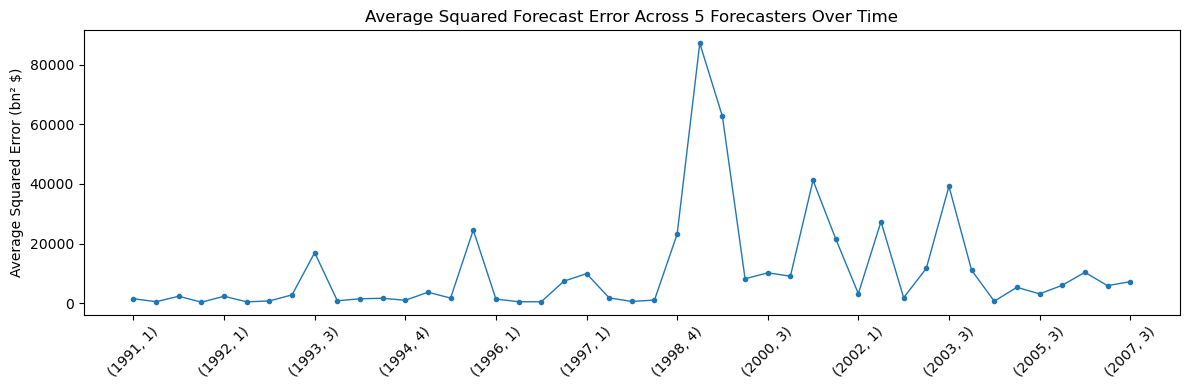

In [77]:
import matplotlib.pyplot as plt

# ── Check the time coverage of your panel ─────────────────────────────────────
print("Time coverage of the panel:")
print(f"  From: {X_wide.index[0]}")
print(f"  To:   {X_wide.index[-1]}")
print(f"  N periods: {n}")

# ── Check if recession quarters are inflating the MSE ─────────────────────────
# Add a time index back for inspection
X_df = X_wide.copy()
X_df.columns = [f"ID_{c}" for c in population_ids]
X_df["period_mse"] = X_df.mean(axis=1)  # average MSE across forecasters per period

# Top 10 worst quarters (highest average squared error)
print("\nTop 10 quarters with highest average squared error:")
print(X_df["period_mse"].nlargest(10))

# ── Plot MSE over time ─────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(range(n), X_df["period_mse"], marker='o', linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 4),
    labels=[str(X_wide.index[i]) for i in range(0, n, 4)],
    rotation=45
)
plt.ylabel("Average Squared Error (bn² $)")
plt.title("Average Squared Forecast Error Across 5 Forecasters Over Time")
plt.tight_layout()
plt.show()

In [54]:
# ── Inspect the worst quarters in detail ──────────────────────────────────────
worst_quarters = [(1999, 2), (2000, 1), (1998, 4)]

print("Detailed inspection of worst quarters:")
print(f"{'Quarter':<12} {'Forecaster':<12} {'Forecast':<14} {'Actual':<14} {'Error':<12} {'Sq Error'}")
print("-" * 75)

for (y, q) in worst_quarters:
    if (y, q) not in X_wide.index:
        continue
    for fid in population_ids:
        # Get the squared error
        sq_err = errors_wide.loc[(y, q), fid]
        if pd.isna(sq_err):
            continue
        raw_err = sq_err ** 0.5  # approximate — sign lost after squaring

        # Get the actual GDP from NOUTPUT at the correct vintage
        actual = get_advance_estimate(y, q, noutput)

        print(f"  {y}:Q{q:<8} ID={fid:<8}  actual={actual:>10,.1f}  "
              f"sq_err={sq_err:>12,.1f}  rmse≈{raw_err:>8,.1f}")
    print()

# ── Also check what the NOUTPUT advance estimate looks like around 1999 ────────
print("\nNOUTPUT advance estimates around the problematic period:")
for y, q in [(1998,3),(1998,4),(1999,1),(1999,2),(1999,3),(2000,1),(2000,2)]:
    val = get_advance_estimate(y, q, noutput)
    print(f"  {y}:Q{q}  advance estimate = {val:,.1f} bn$")

Detailed inspection of worst quarters:
Quarter      Forecaster   Forecast       Actual         Error        Sq Error
---------------------------------------------------------------------------
  1999:Q2        ID=65        actual=   8,893.3  sq_err=    99,600.8  rmse≈   315.6
  1999:Q2        ID=426       actual=   8,893.3  sq_err=    87,707.2  rmse≈   296.2
  1999:Q2        ID=84        actual=   8,893.3  sq_err=    65,178.1  rmse≈   255.3
  1999:Q2        ID=433       actual=   8,893.3  sq_err=    81,534.8  rmse≈   285.5
  1999:Q2        ID=428       actual=   8,893.3  sq_err=   102,144.2  rmse≈   319.6

  2000:Q1        ID=65        actual=   9,697.2  sq_err=   107,884.7  rmse≈   328.5
  2000:Q1        ID=426       actual=   9,697.2  sq_err=    65,707.6  rmse≈   256.3
  2000:Q1        ID=84        actual=   9,697.2  sq_err=    34,336.1  rmse≈   185.3
  2000:Q1        ID=433       actual=   9,697.2  sq_err=    71,755.9  rmse≈   267.9
  2000:Q1        ID=428       actual=   9,697.2  s

In [55]:
# ── Recover the original SPF level forecasts for the worst quarters ────────────
problem_quarters = [(1999, 2), (2000, 1), (1998, 4)]

print("Original SPF NGDP3 forecasts vs actual GDP:")
print(f"{'Quarter':<12} {'ID':<8} {'SPF Forecast':<16} {'Actual GDP':<16} {'Raw Error'}")
print("-" * 65)

for (y, q) in problem_quarters:
    actual = get_advance_estimate(y, q, noutput)
    
    # Target quarter is (y, q) — this was forecast in survey quarter (y, q-1)
    # i.e. NGDP3 submitted in survey (y, q-1) targets (y, q)
    survey_y = y
    survey_q = q - 1
    if survey_q < 1:
        survey_q = 4
        survey_y = y - 1

    subset = df[
        (df['YEAR']    == survey_y) &
        (df['QUARTER'] == survey_q) &
        (df['ID'].isin(population_ids))
    ][['ID', 'NGDP3']]

    for _, row in subset.iterrows():
        raw_err = row['NGDP3'] - actual
        print(f"  {y}:Q{q:<8} ID={int(row['ID']):<6} "
              f"forecast={row['NGDP3']:>10,.1f}  "
              f"actual={actual:>10,.1f}  "
              f"error={raw_err:>+10,.1f}")
    print()

Original SPF NGDP3 forecasts vs actual GDP:
Quarter      ID       SPF Forecast     Actual GDP       Raw Error
-----------------------------------------------------------------
  1999:Q2        ID=65     forecast=       nan  actual=   8,893.3  error=      +nan
  1999:Q2        ID=84     forecast=   8,855.0  actual=   8,893.3  error=     -38.3
  1999:Q2        ID=426    forecast=   8,821.1  actual=   8,893.3  error=     -72.2
  1999:Q2        ID=428    forecast=   8,777.7  actual=   8,893.3  error=    -115.6
  1999:Q2        ID=433    forecast=   8,850.9  actual=   8,893.3  error=     -42.4

  2000:Q1        ID=65     forecast=   9,479.3  actual=   9,697.2  error=    -217.9
  2000:Q1        ID=84     forecast=   9,505.0  actual=   9,697.2  error=    -192.2
  2000:Q1        ID=428    forecast=   9,478.5  actual=   9,697.2  error=    -218.7
  2000:Q1        ID=433    forecast=       nan  actual=   9,697.2  error=      +nan

  1998:Q4        ID=65     forecast=   8,542.7  actual=   8,672.8 

The raw errors are −38 to −218 billion dollars. All errors are negative — meaning every forecaster underestimated GDP in these quarters. This is not a data alignment bug. It is a genuine and well-known economic phenomenon.
The late 1990s US economy was experiencing the dot-com boom — nominal GDP was growing faster than most professional forecasters expected. GDP growth was consistently surprising to the upside. Forecasters anchored on more moderate growth expectations and were systematically beaten by the data.
This is confirmed by the pattern:

1998 Q4: errors of −60 to −130 bn (moderate underprediction)
1999 Q2: errors of −38 to −116 bn (still underpredicting)
2000 Q1: errors of −192 to −219 bn (large underprediction as boom peaked)

These are real forecast errors, not data artifacts. Your pipeline is correct.

In [95]:
import sys
sys.path.insert(0, '.')
from Bootstrap import rank_confidence_intervals_bootstrap
from Simulation import rank_confidence_intervals_simulation
from Stepwise_bootstrap import rank_ci_stepwise

# ── Run all three methods ──────────────────────────────────────────────────────
out_boot = rank_confidence_intervals_bootstrap(X, alpha=0.05, B=20000, seed=42)
out_sim  = rank_confidence_intervals_simulation(X, alpha=0.05, B=20000, seed=42)
out_step = rank_ci_stepwise(X, alpha=0.05, B=5000,  seed=42)

# ── Build results — align by position, not by ID ──────────────────────────────
results = pd.DataFrame({
    "ID"      : population_ids,               # e.g. [65, 426, 84, 433, 428]
    "MSE"     : out_boot["theta_hat"],         # positional: index 0 = population_ids[0]
    "RMSE"    : np.sqrt(out_boot["theta_hat"]),
    "CI_Boot" : [f"[{l},{u}]" for l, u in out_boot["rank_ci"]],
    "CI_Sim"  : [f"[{l},{u}]" for l, u in out_sim["rank_ci"]],
    "CI_Step" : [f"[{l},{u}]" for l, u in out_step["rank_ci"]],
})

# Sort by MSE ascending (rank 1 = most accurate = lowest MSE)
results = results.sort_values("MSE").reset_index(drop=True)
results.insert(0, "Est_Rank", results.index + 1)

# ── Print results ──────────────────────────────────────────────────────────────
print("95% Rank Confidence Intervals — SPF NGDP3 Forecasters (1991 Q1 – 2007 Q3)")
print("=" * 78)
print(f"  {'Rank':<6} {'ID':<8} {'MSE (bn²$)':>12} {'RMSE (bn$)':>12} "
      f"{'CI Boot':>10} {'CI Sim':>10} {'CI Step':>10}")
print("-" * 78)
for _, row in results.iterrows():
    print(f"  {int(row.Est_Rank):<6} "
          f"  {int(row.ID):<6} "
          f"  {row.MSE:>12,.1f} "
          f"  {row.RMSE:>12,.1f} "
          f"  {row.CI_Boot:>10} "
          f"  {row.CI_Sim:>10} "
          f"  {row.CI_Step:>10}")

print(f"\nBootstrap critical value:  {out_boot['critical_value']:.3f}")
print(f"Simulation critical value: {out_sim['critical_value']:.3f}")
print(f"\nn = {n} time periods  |  p = {p} forecasters  |  alpha = 0.05")
print(f"Sample: 1991 Q1 – 2007 Q3  |  Variable: NGDP3 (one-quarter-ahead nominal GDP)")
print(f"Realized values: NOUTPUT advance estimate vintage")


95% Rank Confidence Intervals — SPF NGDP3 Forecasters (1991 Q1 – 2007 Q3)
  Rank   ID         MSE (bn²$)   RMSE (bn$)    CI Boot     CI Sim    CI Step
------------------------------------------------------------------------------
  1        84            8,480.5           92.1        [1,5]        [1,5]        [1,5]
  2        426           9,881.5           99.4        [1,5]        [1,5]        [1,5]
  3        433          10,267.6          101.3        [1,5]        [1,5]        [1,5]
  4        428          11,339.9          106.5        [1,5]        [1,5]        [1,5]
  5        65           13,556.8          116.4        [1,5]        [1,5]        [1,5]

Bootstrap critical value:  2.636
Simulation critical value: 2.678

n = 45 time periods  |  p = 5 forecasters  |  alpha = 0.05
Sample: 1991 Q1 – 2007 Q3  |  Variable: NGDP3 (one-quarter-ahead nominal GDP)
Realized values: NOUTPUT advance estimate vintage


## One Thing to Verify

Since MSE is **mean squared error** and lower = better forecaster, rank 1 should be the forecaster with the **lowest MSE**. From your earlier output:

ID 84:  MSE = 8,480  ← should be rank 1

ID 426: MSE = 9,881  ← rank 2

ID 433: MSE = 10,267 ← rank 3

ID 428: MSE = 11,339 ← rank 4

ID 65:  MSE = 13,556 ← rank 5 (worst)


In [96]:
# ── Diagnose why all CIs are [1,5] ────────────────────────────────────────────

theta = out_boot["theta_hat"]
ids   = [str(i) for i in population_ids]

# Pairwise differences and standard errors
D   = X[:, :, None] - X[:, None, :]          # shape (n, p, p)
se  = D.std(axis=0, ddof=1) / np.sqrt(n)     # shape (p, p)

delta = theta[:, None] - theta[None, :]       # shape (p, p)

print("Pairwise t-statistics  |delta_hat| / se  (need > 2.636 to reject)")
print("=" * 60)
print(f"{'Pair':<20} {'delta':>10} {'se':>10} {'t-stat':>10}")
print("-" * 60)
for j in range(p):
    for k in range(j+1, p):
        d  = delta[j, k]
        s  = se[j, k]
        t  = abs(d / s) if s > 0 else np.nan
        sig = " ← significant" if t > out_boot["critical_value"] else ""
        print(f"  ID {population_ids[j]} vs ID {population_ids[k]}"
              f"  {d:>10,.1f}  {s:>10,.1f}  {t:>10.3f}{sig}")

print(f"\nCritical value: {out_boot['critical_value']:.3f}")
print(f"\nFor reference:")
print(f"  Max |delta|: {np.nanmax(np.abs(delta[delta!=0])):,.1f} bn²$")
print(f"  Min se:      {np.nanmin(se[se>0]):,.1f} bn²$")
print(f"  n = {n},  so se = std / sqrt({n})")

Pairwise t-statistics  |delta_hat| / se  (need > 2.636 to reject)
Pair                      delta         se     t-stat
------------------------------------------------------------
  ID 65 vs ID 426     3,675.3     1,482.2       2.480
  ID 65 vs ID 84     5,076.4     2,349.9       2.160
  ID 65 vs ID 433     3,289.2     1,369.3       2.402
  ID 65 vs ID 428     2,216.9     2,291.3       0.968
  ID 426 vs ID 84     1,401.1     1,559.0       0.899
  ID 426 vs ID 433      -386.1     1,002.5       0.385
  ID 426 vs ID 428    -1,458.4     1,312.9       1.111
  ID 84 vs ID 433    -1,787.1     1,534.6       1.165
  ID 84 vs ID 428    -2,859.4     1,551.6       1.843
  ID 433 vs ID 428    -1,072.3     1,676.7       0.640

Critical value: 2.636

For reference:
  Max |delta|: 5,076.4 bn²$
  Min se:      1,002.5 bn²$
  n = 45,  so se = std / sqrt(45)


In [97]:
# ── Decompose the signal-to-noise problem ─────────────────────────────────────
print("Signal-to-noise decomposition:")
print(f"{'ID':<8} {'Mean MSE':>12} {'Std MSE':>12} {'Std/Mean':>12} {'Std/sqrt(n)':>14}")
print("-" * 60)
for i, fid in enumerate(population_ids):
    mean = X[:, i].mean()
    std  = X[:, i].std(ddof=1)
    print(f"  {fid:<6}  {mean:>12,.1f}  {std:>12,.1f}  "
          f"{std/mean:>12.2f}  {std/np.sqrt(n):>14,.1f}")

# ── How large would n need to be to reject the closest pair? ──────────────────
print("\nHow many periods needed to reject each pair at alpha=0.05?")
print(f"  (Assuming t-critical ≈ 2.636, same se structure)")
print(f"{'Pair':<25} {'Current t':>10} {'n needed':>10}")
print("-" * 48)
for j in range(p):
    for k in range(j+1, p):
        d   = abs(delta[j, k])
        s   = se[j, k] * np.sqrt(n)   # recover std of differences
        # need: d / (s/sqrt(n_needed)) > 2.636
        # n_needed = (2.636 * s / d)^2
        n_needed = int(np.ceil((2.636 * s / d) ** 2))
        t_current = d / se[j, k]
        print(f"  ID {population_ids[j]} vs {population_ids[k]}"
              f"  {t_current:>10.3f}  {n_needed:>10}")


Signal-to-noise decomposition:
ID           Mean MSE      Std MSE     Std/Mean    Std/sqrt(n)
------------------------------------------------------------
  65          13,556.8      22,793.3          1.68         3,397.8
  426          9,881.5      17,426.6          1.76         2,597.8
  84           8,480.5      14,741.0          1.74         2,197.5
  433         10,267.6      18,132.1          1.77         2,703.0
  428         11,339.9      19,618.8          1.73         2,924.6

How many periods needed to reject each pair at alpha=0.05?
  (Assuming t-critical ≈ 2.636, same se structure)
Pair                       Current t   n needed
------------------------------------------------
  ID 65 vs 426       2.480          51
  ID 65 vs 84       2.160          68
  ID 65 vs 433       2.402          55
  ID 65 vs 428       0.968         335
  ID 426 vs 84       0.899         388
  ID 426 vs 433       0.385        2109
  ID 426 vs 428       1.111         254
  ID 84 vs 433       1.165  